# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [3]:
STUDENT_NAME = "Đỗ Đức Duy Thắng"  # TODO: Họ và tên
STUDENT_ID = "24120442"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Đỗ Đức Duy Thắng (24120442)


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/macbook/Documents/ML-BK/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [5]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [6]:
# TODO N1
shifted_logits = logits - np.max(logits, axis = 1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis = 1)

In [7]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [8]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [9]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)
train_feature_std = np.std(X_train, axis = 0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [10]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [11]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [16]:
# TODO N3
correct_mask = true_labels == predicted_classes
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask | ~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [17]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [20]:
# TODO N4
normalized_batch = (image_batch_uint8).astype(np.float32)/255.0
augmented_batch = np.copy(normalized_batch[:, :, ::-1, :])
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

# Automobile Data Dictionary

Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
Giá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.

| Column | Expected type | Meaning | Unit / values | Missing |
|---|---|---|---|---:|
| `symboling` | integer | Mức đánh giá rủi ro bảo hiểm | -3 đến 3 | 0 |
| `normalized_losses` | numeric | Mức tổn thất bảo hiểm trung bình đã chuẩn hóa | relative score | 41 |
| `make` | categorical | Hãng sản xuất | - | 0 |
| `fuel_type` | categorical | Loại nhiên liệu | gas/diesel | 0 |
| `aspiration` | categorical | Cơ chế nạp khí của động cơ | std/turbo | 0 |
| `num_doors` | categorical | Số cửa | two/four | 2 |
| `body_style` | categorical | Kiểu thân xe | - | 0 |
| `drive_wheels` | categorical | Hệ dẫn động | fwd/rwd/4wd | 0 |
| `engine_location` | categorical | Vị trí động cơ | front/rear | 0 |
| `wheel_base` | numeric | Khoảng cách giữa tâm hai trục bánh xe | inches | 0 |
| `length` | numeric | Chiều dài xe | inches | 0 |
| `width` | numeric | Chiều rộng xe | inches | 0 |
| `height` | numeric | Chiều cao xe | inches | 0 |
| `curb_weight` | numeric | Khối lượng xe với trang bị tiêu chuẩn | pounds | 0 |
| `engine_type` | categorical | Kiến trúc động cơ | - | 0 |
| `num_cylinders` | categorical | Số xi-lanh | - | 0 |
| `engine_size` | numeric | Dung tích động cơ | cubic inches | 0 |
| `fuel_system` | categorical | Loại hệ thống nhiên liệu | - | 0 |
| `bore` | numeric | Đường kính xi-lanh | inches | 4 |
| `stroke` | numeric | Hành trình piston | inches | 4 |
| `compression_ratio` | numeric | Tỷ số nén | ratio | 0 |
| `horsepower` | numeric | Công suất động cơ | hp | 2 |
| `peak_rpm` | numeric | Tốc độ động cơ tại công suất cực đại | rpm | 2 |
| `city_mpg` | numeric | Mức tiết kiệm nhiên liệu trong đô thị | miles per gallon | 0 |
| `highway_mpg` | numeric | Mức tiết kiệm nhiên liệu trên cao tốc | miles per gallon | 0 |
| `price` | numeric | Giá xe | USD | 4 |

## Core analysis columns

Các bài NumPy định lượng sử dụng 6 cột sau:

`curb_weight`, `engine_size`, `horsepower`, `city_mpg`, `highway_mpg`, `price`

## Source

- UCI Machine Learning Repository: Automobile dataset.
- Original data file: `imports-85.data`.
- Dataset DOI: <https://doi.org/10.24432/C5B01C>.
- UCI lists the dataset under the CC BY 4.0 license.


**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [25]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').values.sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [26]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [27]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isnull().sum()

In [40]:
missing_by_column

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Vì tuỳ từng dữ liệu mà ta xử lý missing values khác nhau cho nên khi điền tất cả giá trị còn thiếu cùng 1 giá trị sẽ
làm mô hình học trên 1 tập dữ liệu giả và dẫn đến dự đoán kết quả sai hoàn toàn.
- Với price thì ta nên drop vì đây là biến mục tiêu
- normalized_losses thiếu nhiều dữ liệu ảnh hưởng rất lớn đến việc huấn luyện, nếu bỏ tất cả các mẫu thiếu thì sẽ hao hụt
rất nhiều dữ liệu nên ta chọn cách điền theo trung bình của kiểu dáng xe

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [28]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [30]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = np.array(analysis_df[AUTO_FEATURES], dtype = np.float64)
auto_feature_mean = np.mean(X_auto, axis = 0)
auto_feature_std = np.std(X_auto, axis = 0)
X_auto_scaled = (X_auto - auto_feature_mean)/auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [37]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:,price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [39]:
# TODO D5
engine_price_corr = np.corrcoef(X_auto_scaled[:, price_index], X_auto_scaled[:, AUTO_FEATURES.index('engine_size')])[0,1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

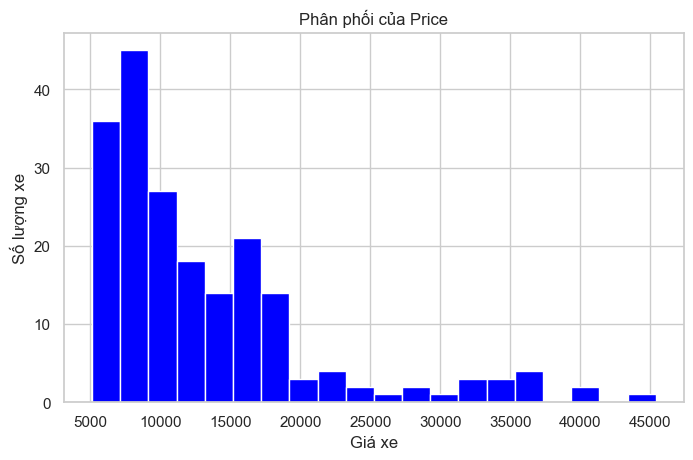

In [41]:
# TODO M2.1: histogram/KDE của price
plt.hist(df_clean['price'], bins = 20, color = 'blue')
plt.title('Phân phối của Price')
plt.xlabel('Giá xe')
plt.ylabel('Số lượng xe')
plt.show()

**Nhận xét:** Phân phối của giá xe lệch phải, tập dữ liệu chủ yếu tập trung ở các xe có phân khúc thấp từ 5000$-15000$

## M2.2 Dataset có cân bằng theo body style không?

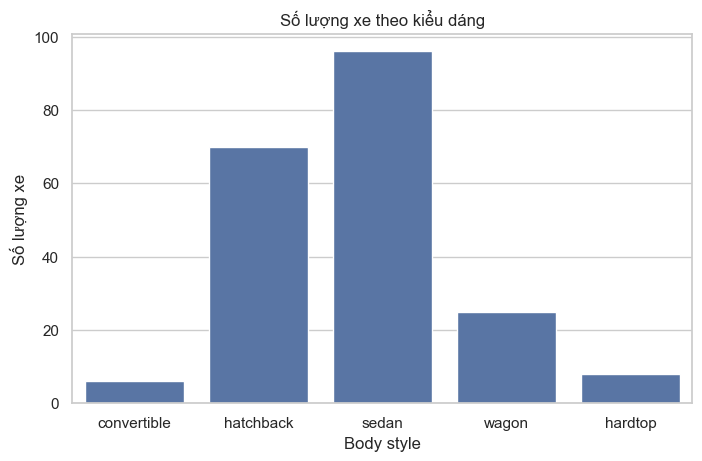

In [43]:
# TODO M2.2: countplot của body_style
sns.countplot(df_clean, x='body_style')
plt.title('Số lượng xe theo kiểu dáng')
plt.xlabel('Body style')
plt.ylabel('Số lượng xe')
plt.show()

**Nhận xét:** Tập dữ liệu không cân bằng theo body style, tập trung chủ yếu ở 2 body style là sedan và hatchback, cái body style còn lại thì dữ liệu khá ít gây ra mất cân bằng nghiêm trọng

## M2.3 Price khác nhau theo body style ra sao?

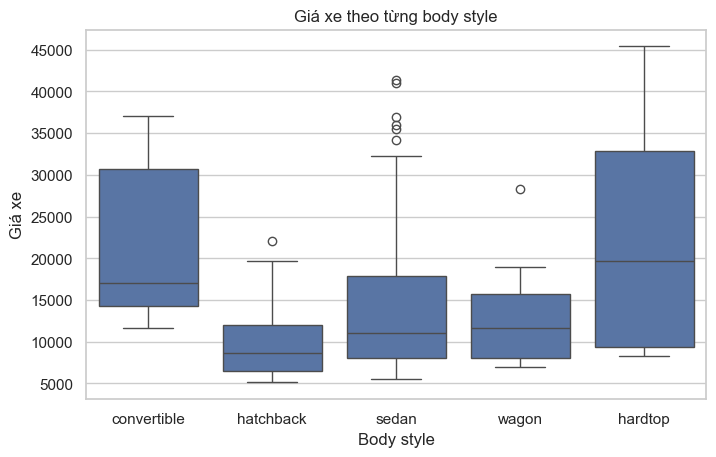

In [44]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data = df_clean, x = 'body_style', y = 'price')
plt.title('Giá xe theo từng body style')
plt.xlabel('Body style')
plt.ylabel('Giá xe')
plt.show()

**Nhận xét:** Giá trung bình của style body thuộc hatchback, sedan, wagon tương đối bằng nhau, ít biến động hơn và giá trị trung bình thấp hơn so với vonertible và hardtop

## M2.4 Engine size liên quan thế nào tới price?

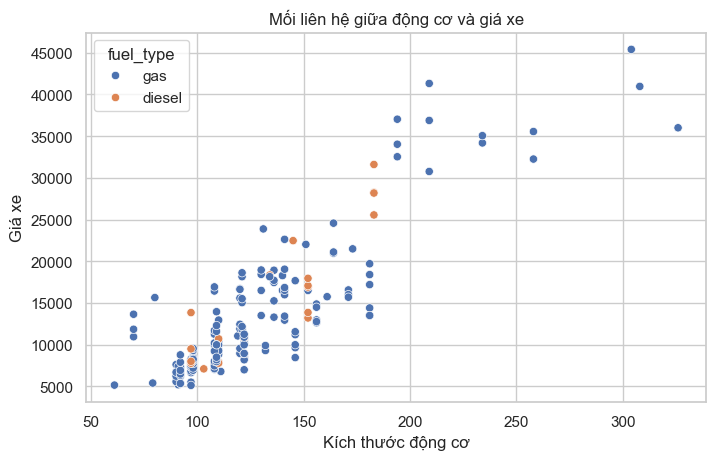

In [46]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data = df_clean, x='engine_size', y ='price', hue = 'fuel_type' )
plt.title('Mối liên hệ giữa động cơ và giá xe')
plt.xlabel('Kích thước động cơ')
plt.ylabel('Giá xe')
plt.show()


**Nhận xét:** Có thể thấy mối liên hệ giữa kích thước động cơ và giá xe là tuyến tính, bên cạnh đó biểu đồ còn cho thấy dữ liệu có rất nhiều loại động cơ gas, còn động cơ diesel khá ít dẫn đến chênh lệch giữa loại nguyên liệu sử dụng của động cơ

## M2.5 Các feature numeric tương quan ra sao?

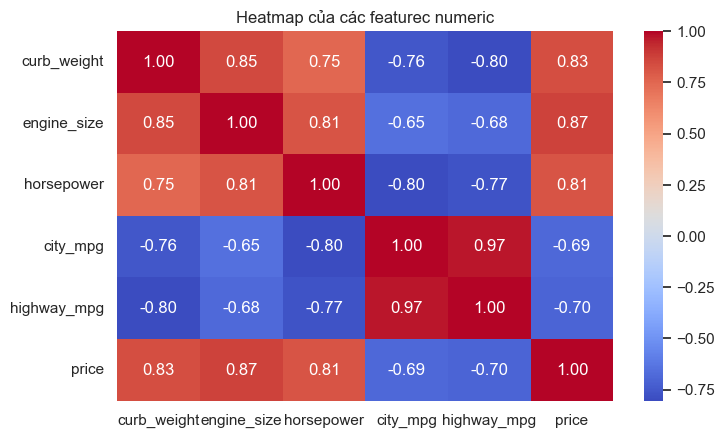

In [ ]:
# TODO M2.5: correlation heatmap
corr_matrix = df_clean[AUTO_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt ='.2f')
plt.title('Heatmap của các features numeric')
plt.show()

**Nhận xét:** Mức độ tương quan giữa các dữ liệu trong tập dữ liệu khá lớn, có thể nói đến như highway_mpg và city_mpg, horsepower và engine_size,...

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

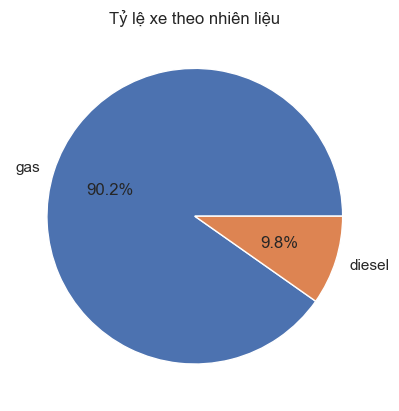

In [50]:
# TODO M2.6: biểu đồ tự chọn
# tỉ lệ giữa xe chạy gas và diesel là bao nhiêu
fuel_counts = df_clean['fuel_type'].value_counts()
plt.pie(fuel_counts, labels = fuel_counts.index, autopct='%1.1f%%')
plt.title('Tỷ lệ xe theo nhiên liệu')
plt.show()

**Nhận xét:** Tỉ lệ giữa xe chạy gas và diesel chênh lệch rất lớn hơn 9 lần dẫn đến việc khi sử dụng mô hình có thể gây ra thiên kiến

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

### 1. Các phát hiện:
- Phần lớn xe tập trung ở phân khúc thấp đến bình dân, M2.1 cho thấy phân phối của Price có dạng lệch phải và dữ liệu tập trung chủ yếu ở 5000$-15000$
- Engine_size có tương quan rất lớn so với price, Heatmap ở M2.5 và biểu đồ ở M2.4 cho thấy điều này, mối quan hệ giữa engine_size và price là tuyến tính và có hệ số tương quan là 0.87
- Dữ liệu tập trung chủ yếu ở 3 style body là hatchback, sedan và wagon thể hiện ở biểu đồ M2.2, cho thấy dữ liệu bị mất cân bằng
### 2. Hạn chế của dataset:
- Thiếu rất nhiều dữ liệu quan trọng (khoảng 20%) ở cột normalized_losses gây khó khăn trong việc phân tích và huấn luyện mô hình sau này
- Mất cân bằng dữ liệu nghiêm trọng ở các dữ liệu như fuel_type, style_body và price. Dẫn đến khi xây dựng mô hình sẽ dễ gây thiên kiến và dự đoán không chính xác cho các loại dữ liệu ít có trong dataset
### 3. Ví dụ:
- Nhìn vào biểu đồ Heatmap (M2.5), ta thấy biến curb_weight (trọng lượng không tải) có tương quan dương rất mạnh (0.83) với price (giá xe). Nhưng thực tế trọng lượng không tạo ra giá trị, thực chất curb_weight và engine_size mới là nguyên nhân chính, những xe đắt tiền thường có động cơ lớn, khung gầm lớn, vỏ chắn chắn,... dẫn đến chiếc xe sẽ nặng hơn nhưng nó không phải là nguyên nhân trực tiếp tăng giá.
### 4. Câu hỏi: 
- Make(thương hiệu) ảnh hưởng như thế nào đến price nếu giữ nguyên engine_size, fuel_type,...